In [1]:
%pip install pandas numpy matplotlib scikit-learn seaborn


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

Mean Absolute Error: $35,682.61
R² Score: -0.3123


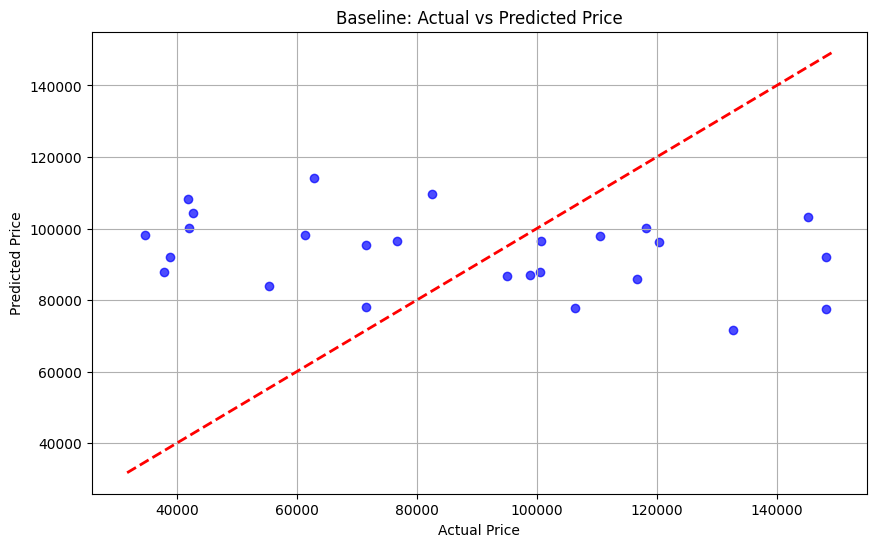

In [3]:
# 1. Load your uploaded files
# Ensure these filenames match exactly what is in your folder
market_data = pd.read_csv('compiled_yearly_ev_market_data.csv')
vehicle_data = pd.read_csv('compiled_vehicle_models_data.csv')

# 2. Data Cleaning & Merging
# Standardize column names to lowercase to avoid "KeyError"
market_data.columns = [c.lower() for c in market_data.columns]
vehicle_data.columns = [c.lower() for c in vehicle_data.columns]

# Rename columns to match our code expectations
# We map the actual CSV headers to the variable names we want
vehicle_data = vehicle_data.rename(columns={
    'model_name': 'Model', 
    'brand': 'Manufacturer',
    'battery_capacity_kwh': 'battery_capacity_kwh',
    'price_usd': 'Price_USD',
    'year': 'Year',
    'range_km': 'range_km'
})
market_data = market_data.rename(columns={
    'year': 'Year',
    'battery_price_usd_per_kwh': 'Battery_Price_USD_per_kWh'
})

# We need rows that have BOTH Price and Battery Specs
clean_df = vehicle_data.dropna(subset=['Price_USD', 'battery_capacity_kwh', 'range_km'])

# Ensure Year column is integer for merging
market_data['Year'] = market_data['Year'].astype(int)
clean_df['Year'] = clean_df['Year'].astype(int)

# Merge to get "Battery_Price_USD_per_kWh" into the vehicle data
merged_df = pd.merge(clean_df, market_data[['Year', 'Battery_Price_USD_per_kWh']], on='Year', how='left')

# --- THE FIX IS HERE ---
# Fill any missing battery prices with forward fill, then backward fill
merged_df['Battery_Price_USD_per_kWh'] = merged_df['Battery_Price_USD_per_kWh'].ffill().bfill()

# 3. Feature Engineering (KM -> Miles)
merged_df['range_miles'] = merged_df['range_km'] * 0.621371

# Select the features we want to train on
# Note: We capitalize 'Year' and 'Price_USD' because we renamed them above
features = ['battery_capacity_kwh', 'range_miles', 'Year', 'Battery_Price_USD_per_kWh']
target = 'Price_USD'

X = merged_df[features]
y = merged_df[target]

# 4. Train the Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Polynomial Features (Degree 2)
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Fit Regression
model = LinearRegression()
model.fit(X_poly_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_poly_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R² Score: {r2:.4f}")

# 6. Plotting
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Baseline: Actual vs Predicted Price')
plt.grid(True)
plt.show()

In [4]:
# Select Features
X = merged_df[['battery_capacity_kwh', 'range_miles', 'Year', 'Battery_Price_USD_per_kWh']]
y = merged_df['Price_USD']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial Fit
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)

model = LinearRegression()
model.fit(X_poly, y_train)

# Output Accuracy
r2 = model.score(poly.transform(X_test), y_test)
print(f"Baseline R2 Accuracy: {r2:.2f}")

Baseline R2 Accuracy: -0.31


# 📖 Data Dictionary

## 1. Primary Datasets
The model relies on two primary data sources: `cleaned_ev_specs.csv` (Technical Specifications) and `ev_prices_sold.csv` (Market Data).

### **A. Technical Specifications (`cleaned_ev_specs.csv`)**
| Column Name | Data Type | Description | Unit |
| :--- | :--- | :--- | :--- |
| `brand` | String | Manufacturer of the vehicle (e.g., Tesla, Porsche). | N/A |
| `model` | String | Specific model name (e.g., Model 3, Taycan). | N/A |
| `battery_capacity_kWh` | Float | Usable energy capacity of the battery. | kWh |
| `battery_type` | String | Chemistry type (e.g., Lithium-ion, LFP). | Categorical |
| `range_km` | Float | Maximum driving range on a single charge (WLTP/EPA). | Kilometers |
| `top_speed_kmh` | Float | Maximum achievable speed. | km/h |
| `acceleration_0_100_s` | Float | Time to accelerate from 0 to 100 km/h. | Seconds |
| `efficiency_wh_per_km` | Float | Energy consumption rate. Lower is better. | Wh/km |
| `fast_charging_power_kw_dc`| Float | Max charging speed at a DC fast charger. | kW |
| `drivetrain` | String | Configuration (AWD, RWD, FWD). | Categorical |
| `segment` | String | Market segment (e.g., SUV, Sedan, Luxury). | Categorical |

### **B. Market & Pricing Data (`ev_prices_sold.csv`)**
| Column Name | Data Type | Description | Unit |
| :--- | :--- | :--- | :--- |
| `Vehicle_ID` | Integer | Unique identifier for the transaction record. | ID |
| `Model` | String | Model name (Key for joining with Specs). | N/A |
| `Year` | Integer | Model year of the vehicle. | Year |
| `Price_USD` | Float | Market price of the vehicle. | $ USD |
| `Units_Sold_2024` | Integer | Total units sold in the fiscal year 2024. | Count |

## 2. Engineered Features (Pre-Processing)
The following features were created during the `02_baseline_model` phase to normalize units for U.S. market analysis.

| Feature Name | Derived From | Formula / Logic | Unit |
| :--- | :--- | :--- | :--- |
| `range_miles` | `range_km` | `range_km * 0.621371` | Miles |
| `top_speed_mph` | `top_speed_kmh` | `top_speed_kmh * 0.621371` | MPH |

In [5]:
# Save the processed data for the next notebook
merged_df.to_csv('processed_ev_data.csv', index=False)
print("✅ Data saved to 'processed_ev_data.csv'")

✅ Data saved to 'processed_ev_data.csv'
